# Multilingual LLM-as-a-Judge Prompting Benchmark — Analysis Notebook

**Thesis:** Evaluating the Transferability and Robustness of LLM-as-a-Judge Prompting Protocols in Multilingual Scenarios  
**Author:** Asal Mehrabi | University of Amsterdam / CWI  
**Supervisor:** Clemencia Siro

This notebook reproduces all figures and tables presented in the thesis from `all_results_v4.csv`.

## Contents
1. Setup
2. **SRQ1** — Strategy Scoring Consistency
   - Figure 1: Mean judge scores per strategy and resource tier (MT, Sum, QA, Math)
   - Table 2: Cross-language range per strategy and resource tier
   - Table 3: Inter-model Spearman ρ on strategy rankings
   - Table 4: Inter-model Pearson r on absolute scores
3. **SRQ2** — Sources of Cross-Language Variance
   - Table 5: Variance decomposition (η²) — two-way ANOVA + one-way ANOVAs
   - Appendix: Cross-language CV per strategy (Table CV)
   - Appendix: Per-model strategy × dataset heatmaps (Figures A1–A4)
4. **SRQ3** — Resource Level and Target-Language Prompting
   - Figure 2: Monolingual Δ per language and judge model
   - Table 6: English–low-resource scoring gap per strategy and task
5. **SRQ4** — External Validity
   - Table 7: Spearman ρ vs human annotations (SSA-MTE, SummEval, WMT MQM)
6. **Appendix** — Rubric dimension analysis
   - Figure A5: Mean rubric dimension scores per strategy
   - Figure A6: MT rubric dimensions by resource tier
   - Figure A7: Summarization rubric dimensions by resource tier

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
DATA_PATH = Path('all_results_v4.csv')   # change if needed
FIGDIR    = Path('figures')
FIGDIR.mkdir(exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,} | Models: {df.model.nunique()} | '
      f'Strategies: {df.strategy.nunique()} | '
      f'Languages: {df.lang.nunique()} | Tasks: {df.task.nunique()}')

/Users/asal/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Rows: 2,876 | Models: 4 | Strategies: 9 | Languages: 27 | Tasks: 4


In [2]:
# ── Constants ─────────────────────────────────────────────────────────
MODEL_LABELS = {
    'aya-expanse-32b': 'Aya 32B',
    'gemma-3-27b-it':  'Gemma 27B',
    'qwen-2.5-32b':    'Qwen 32B',
    'qwen-2.5-72b':    'Qwen 72B',
}
# ── Canonical orderings & labels ──
MODEL_ORDER  = ['aya-expanse-32b', 'gemma-3-27b-it', 'qwen-2.5-32b', 'qwen-2.5-72b']
MODEL_LABELS = {'aya-expanse-32b':'Aya 32B', 'gemma-3-27b-it':'Gemma 27B',
                'qwen-2.5-32b':'Qwen 32B', 'qwen-2.5-72b':'Qwen 72B'}
MODEL_COLORS = {'aya-expanse-32b':'#1b9e77', 'gemma-3-27b-it':'#d95f02',
                'qwen-2.5-32b':'#7570b3', 'qwen-2.5-72b':'#e7298a'}

STRAT_ORDER  = ['zero_shot','few_shot_anchored','prometheus','cot','cross_lingual',
                'monolingual','translate_then_evaluate','role_prompting','self_consistency']
STRAT_LABELS = {'zero_shot':'Zero-Shot','few_shot_anchored':'Few-Shot','prometheus':'Prometheus',
                'cot':'CoT','cross_lingual':'Cross-Ling.','monolingual':'Monolingual',
                'translate_then_evaluate':'Trans-Eval','role_prompting':'Role','self_consistency':'Self-Cons.'}

TASK_ORDER = ['MT','Sum','QA','Math']
RES_ORDER  = ['high','mid','low-mid','low']
RES_COLORS = {'high':'#2166ac','mid':'#67a9cf','low-mid':'#ef8a62','low':'#b2182b'}


# Single-task languages excluded from monolingual Δ analysis
SINGLE_TASK_LANGS = ['ara', 'bem', 'deu', 'fon', 'lug', 'som', 'tir']
EXCLUDE_MONO     = SINGLE_TASK_LANGS + ['eng']   # also exclude English

print('Setup complete.')

Setup complete.


---
## 2. SRQ1 — Strategy Scoring Consistency

### Figure 1 — Mean judge scores per strategy and resource tier

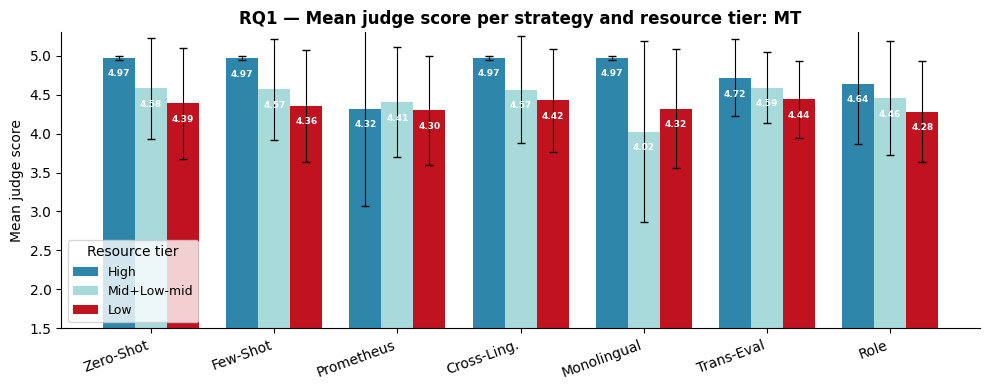

Saved: rq1_mt_by_resource.png


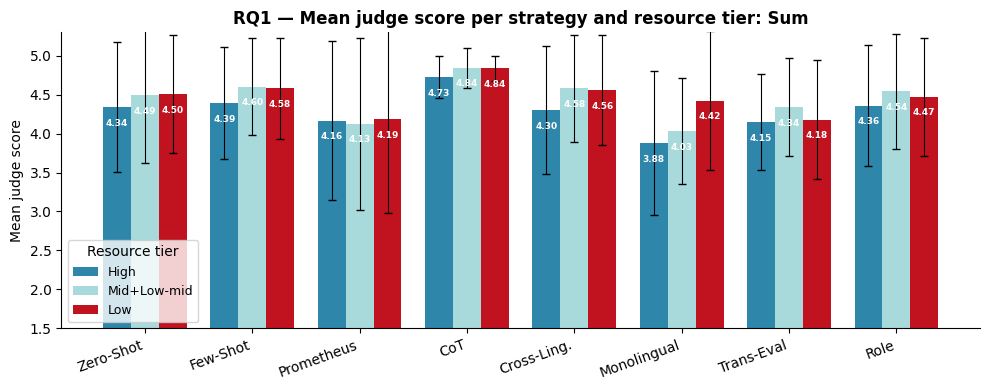

Saved: rq1_sum_by_resource.png


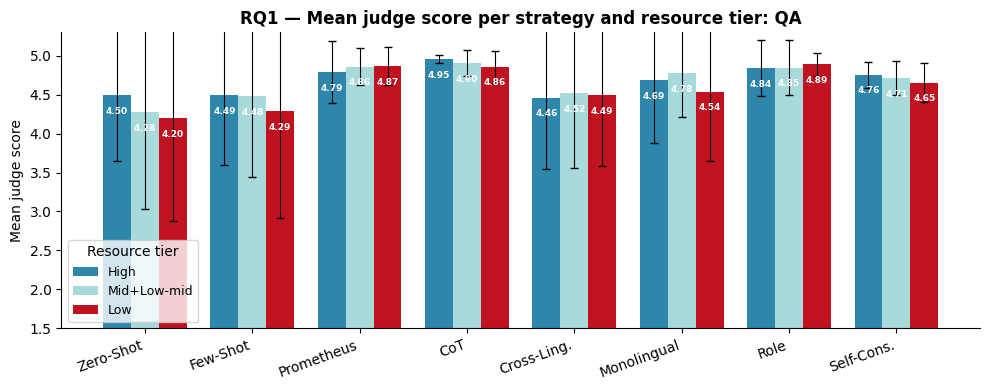

Saved: rq1_qa_by_resource.png


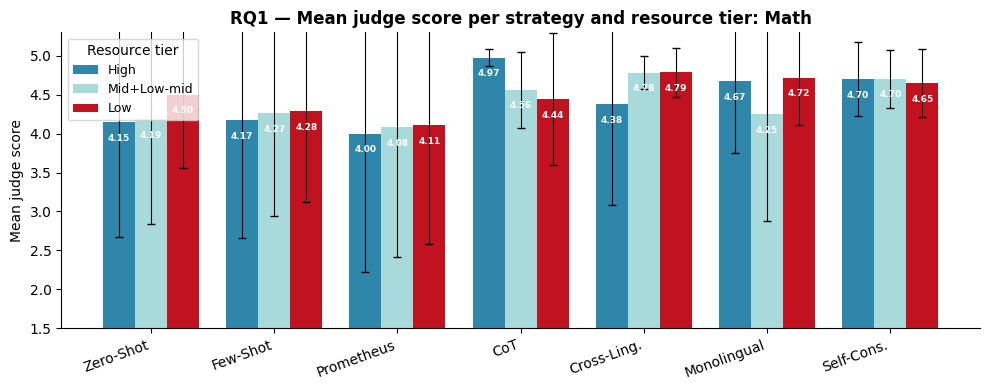

Saved: rq1_math_by_resource.png


In [3]:
# Group mid and low-mid into one tier for display
df['res_group'] = df['resource'].map({
    'high': 'High', 'mid': 'Mid+Low-mid',
    'low-mid': 'Mid+Low-mid', 'low': 'Low'
})
RES_GROUPS  = ['High', 'Mid+Low-mid', 'Low']
RES_GCOLORS = {'High': '#2E86AB', 'Mid+Low-mid': '#A8DADC', 'Low': '#C1121F'}

for task in ['MT', 'Sum', 'QA', 'Math']:
    task_sub = df[df['task'] == task]
    strats   = [s for s in STRAT_ORDER if s in task_sub.strategy.unique()]

    fig, ax = plt.subplots(figsize=(10, 4))
    x       = np.arange(len(strats))
    width   = 0.26

    for i, rg in enumerate(RES_GROUPS):
        sub   = task_sub[task_sub['res_group'] == rg]
        means = [sub[sub.strategy == s]['mean'].mean() for s in strats]
        stds  = [sub[sub.strategy == s]['mean'].std()  for s in strats]
        bars  = ax.bar(x + i * width, means, width,
                       label=rg, color=RES_GCOLORS[rg],
                       yerr=stds, capsize=3, error_kw={'linewidth': 0.8})
        for bar, m in zip(bars, means):
            if not np.isnan(m):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.15,
                        f'{m:.2f}', ha='center', va='top',
                        fontsize=6.5, color='white', fontweight='bold')

    ax.set_xticks(x + width)
    ax.set_xticklabels([STRAT_LABELS[s] for s in strats], rotation=20, ha='right')
    ax.set_ylim(1.5, 5.3)
    ax.set_ylabel('Mean judge score')
    ax.set_title(f'RQ1 — Mean judge score per strategy and resource tier: {task}',
                 fontweight='bold')
    ax.legend(title='Resource tier', fontsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGDIR / f'rq1_{task.lower()}_by_resource.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: rq1_{task.lower()}_by_resource.png')

### Table 2 — Cross-language range per strategy and resource tier (MT + Sum)

In [4]:
def cross_lang_range(sub):
    lm = sub.groupby('lang')['mean'].mean()
    return (lm.max() - lm.min()) if len(lm) >= 2 else np.nan

print('Cross-language range (max-min of per-language means)\n')
print(f'{"Strategy":12}  {"MT-H":>6} {"MT-M":>6} {"MT-LM":>6} {"MT-L":>6}  '
      f'{"Sum-H":>6} {"Sum-M":>6} {"Sum-LM":>6} {"Sum-L":>6}')

for s in STRAT_ORDER:
    row = STRAT_LABELS.get(s, s)
    for task in ['MT', 'Sum']:
        tsub = df[(df.task == task) & (df.strategy == s)]
        for res in RES_ORDER:
            v = cross_lang_range(tsub[tsub.resource == res])
            row += f'  {v:6.2f}' if not np.isnan(v) else f'  {"---":>6}'
    print(row)

Cross-language range (max-min of per-language means)

Strategy        MT-H   MT-M  MT-LM   MT-L   Sum-H  Sum-M Sum-LM  Sum-L
Zero-Shot    0.01    0.05    0.10    1.74    0.43    0.05    0.12    0.24
Few-Shot    0.02    0.01    0.12    1.77    0.31    0.03    0.03    0.21
Prometheus    0.18    0.35    0.04    1.69    0.54    0.30    0.13    0.19
CoT     ---     ---     ---     ---    0.25    0.30    0.06    0.13
Cross-Ling.    0.03    0.06    0.23    1.58    0.22    0.06    0.00    0.27
Monolingual    0.03    0.38    0.12    1.58    1.05    0.03    0.04    1.15
Trans-Eval    0.12    0.09    0.19    1.33    0.47    0.28    0.16    0.42
Role    0.54    0.07    0.29    1.52    0.42    0.02    0.01    0.35
Self-Cons.     ---     ---     ---     ---     ---     ---     ---     ---


### Table 3 — Inter-model Spearman ρ on strategy rankings

In [5]:
from itertools import combinations

models_present = [m for m in MODEL_ORDER if m in df.model.unique()]
def mean_spearman_rank(task, resource):
    sub = df[(df.task == task) & (df.resource == resource)]
    rhos = []
    for m1, m2 in combinations(models_present, 2):
        s1 = sub[sub.model == m1].groupby('strategy')['mean'].mean()
        s2 = sub[sub.model == m2].groupby('strategy')['mean'].mean()
        common = s1.index.intersection(s2.index)
        if len(common) >= 3:
            rho, _ = spearmanr(s1[common], s2[common])
            rhos.append(rho)
    return np.mean(rhos) if rhos else np.nan

print('Inter-model Spearman ρ (mean across 6 model pairs)\n')
print(f'{"Task":6} {"High":>8} {"Mid":>8} {"Low-mid":>8} {"Low":>8}')
for task in ['MT', 'Sum', 'QA']:
    row = f'{task:6}'
    for res in RES_ORDER:
        v = mean_spearman_rank(task, res)
        row += f' {v:+8.2f}' if not np.isnan(v) else f' {"---":>8}'
    print(row)
print('(Math excluded: insufficient cross-tier language coverage)')

Inter-model Spearman ρ (mean across 6 model pairs)

Task       High      Mid  Low-mid      Low
MT        +0.46    +0.02    +0.39    +0.04
Sum       -0.30    -0.20    +0.10    -0.02
QA        -0.00    -0.08    +0.02    -0.04
(Math excluded: insufficient cross-tier language coverage)


### Table 4 — Inter-model Pearson r on absolute scores

In [6]:
# Correct method — matches thesis Table 4
pivot = df.pivot_table(
    index=['strategy', 'task', 'lang', 'dataset'],
    columns='model',
    values='mean'
).dropna()
pivot = pivot[[m for m in models_present if m in pivot.columns]]

print('Inter-model Pearson r (all tasks pooled)\n')
labels = [MODEL_LABELS[m] for m in models_present]
print(f'{"":12}' + ''.join(f'{l:>12}' for l in labels))
for m1 in models_present:
    row = f'{MODEL_LABELS[m1]:12}'
    for m2 in models_present:
        if m1 == m2:
            row += f'{1.000:>12.3f}'
        else:
            r, _ = pearsonr(pivot[m1], pivot[m2])
            row += f'{r:>12.3f}'
    print(row)

Inter-model Pearson r (all tasks pooled)

                 Aya 32B   Gemma 27B    Qwen 32B    Qwen 72B
Aya 32B            1.000      -0.173       0.385       0.411
Gemma 27B         -0.173       1.000       0.003       0.025
Qwen 32B           0.385       0.003       1.000       0.819
Qwen 72B           0.411       0.025       0.819       1.000


---
## 3. SRQ2 — Sources of Cross-Language Variance

### Table 5 — Variance decomposition (η²)

In [7]:
def two_way_anova(sub):
    """Two-way ANOVA: judge + strategy + interaction. Returns eta2 dict."""
    model = smf.ols(
        'mean ~ C(model) + C(strategy) + C(model):C(strategy)',
        data=sub
    ).fit()
    table = anova_lm(model, typ=2)
    sst = table['sum_sq'].sum() + model.ssr
    return {
        'judge':       table.loc['C(model)',            'sum_sq'] / sst,
        'strategy':    table.loc['C(strategy)',          'sum_sq'] / sst,
        'interaction': table.loc['C(model):C(strategy)', 'sum_sq'] / sst,
    }

def one_way_eta2(sub, factor):
    groups = [g['mean'].dropna().values for _, g in sub.groupby(factor)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return np.nan
    allv  = np.concatenate(groups)
    grand = allv.mean()
    ss_b  = sum(len(g) * (g.mean() - grand)**2 for g in groups)
    ss_t  = ((allv - grand)**2).sum()
    return ss_b / ss_t

tasks = ['MT', 'Sum', 'QA', 'Math']
# MT without SSA-MTE
mt_no_ssa = df[(df.task == 'MT') & (df.dataset != 'ssa_mte')]

results = {}
for t in tasks + ['MT_noSSA']:
    sub = df[df.task == t] if t in tasks else mt_no_ssa
    anova = two_way_anova(sub)
    results[t] = {
        **anova,
        'language': one_way_eta2(sub, 'lang'),
        'resource': one_way_eta2(sub, 'resource'),
    }

# Overall
ov = two_way_anova(df)
results['Overall'] = {
    **ov,
    'language': one_way_eta2(df, 'lang'),
    'resource': one_way_eta2(df, 'resource'),
}

factors = ['judge', 'strategy', 'interaction', 'language', 'resource']
labels  = ['Judge model', 'Strategy', 'Judge × Strat', 'Language†', 'Resource†']
cols    = ['Overall', 'MT', 'MT_noSSA', 'Sum', 'QA', 'Math']

print('Variance decomposition (η²)\n')
print(f'{"Factor":16}' + ''.join(f'{c:>12}' for c in cols))
for f, l in zip(factors, labels):
    row = f'{l:16}'
    for c in cols:
        v = results[c].get(f, np.nan)
        row += f'{v:>12.3f}' if not np.isnan(v) else f'{"---":>12}'
    print(row)
print('\n† One-way ANOVA | MT_noSSA = SSA-MTE excluded')

Variance decomposition (η²)

Factor               Overall          MT    MT_noSSA         Sum          QA        Math
Judge model            0.087       0.006       0.048       0.438       0.251       0.221
Strategy               0.012       0.007       0.035       0.057       0.059       0.036
Judge × Strat          0.056       0.017       0.114       0.165       0.247       0.297
Language†              0.043       0.325       0.030       0.032       0.012       0.010
Resource†              0.007       0.051       0.008       0.010       0.003       0.001

† One-way ANOVA | MT_noSSA = SSA-MTE excluded


### Appendix — Cross-language CV per strategy (Table CV)

In [8]:
def cv_of(sub):
    lm = sub.groupby('lang')['mean'].mean()
    if len(lm) < 2 or lm.mean() == 0:
        return np.nan
    return lm.std() / lm.mean()

mtsum = df[df['task'].isin(['MT', 'Sum'])]

print('Cross-language CV per strategy (MT+Sum)\n')
print(f'{"Strategy":13}' +
      ''.join(f'{MODEL_LABELS[m]:>9}' for m in models_present) +
      f'{"Mean":>9}  {"High":>7} {"Low":>7}  {"MT":>7} {"Sum":>7}')

rows = []
for s in STRAT_ORDER:
    s_sub = mtsum[mtsum.strategy == s]
    if len(s_sub) == 0:
        continue
    cvs  = [cv_of(s_sub[s_sub.model == m]) for m in models_present]
    mean = np.nanmean(cvs)
    high = cv_of(s_sub[s_sub.resource == 'high'])
    low  = cv_of(s_sub[s_sub.resource == 'low'])
    mt_  = cv_of(df[(df.strategy == s) & (df.task == 'MT')])
    sm_  = cv_of(df[(df.strategy == s) & (df.task == 'Sum')])
    rows.append((STRAT_LABELS[s], cvs, mean, high, low, mt_, sm_))

rows.sort(key=lambda r: r[2])
for name, cvs, mean, high, low, mt_, sm_ in rows:
    row = f'{name:13}'
    for v in cvs:
        row += f'{v:>9.3f}' if not np.isnan(v) else f'{"---":>9}'
    row += f'{mean:>9.3f}'
    for v in [high, low, mt_, sm_]:
        row += f'{v:>7.3f}' if not np.isnan(v) else f'{"---":>7}'
    print(row)

Cross-language CV per strategy (MT+Sum)

Strategy       Aya 32BGemma 27B Qwen 32B Qwen 72B     Mean     High     Low       MT     Sum
CoT              0.070    0.024    0.012    0.039    0.036  0.030  0.009    ---  0.021
Trans-Eval       0.078    0.105    0.137    0.092    0.103  0.080  0.081  0.086  0.041
Cross-Ling.      0.080    0.118    0.140    0.151    0.122  0.057  0.120  0.124  0.030
Role             0.093    0.123    0.140    0.160    0.129  0.062  0.125  0.129  0.032
Few-Shot         0.092    0.116    0.141    0.181    0.133  0.059  0.138  0.140  0.025
Zero-Shot        0.087    0.134    0.146    0.173    0.135  0.075  0.133  0.137  0.031
Monolingual      0.186    0.114    0.163    0.184    0.162  0.166  0.122  0.132  0.099
Prometheus       0.107    0.236    0.140    0.176    0.165  0.059  0.115  0.117  0.033


### Appendix — Per-model heatmaps (Figures A1–A4)

In [9]:
def lang_mean_range(cell):
    lm = cell.groupby('lang')['mean'].mean()
    return lm.mean(), (lm.max() - lm.min()) if len(lm) >= 2 else np.nan

for task in ['MT', 'Sum', 'QA', 'Math']:
    task_sub    = df[df['task'] == task]
    strats_task = [s for s in STRAT_ORDER if s in task_sub.strategy.unique()]
    yl          = [STRAT_LABELS[s] for s in strats_task]
    res_present = [r for r in RES_ORDER if len(task_sub[task_sub.resource == r]) > 0]

    all_ranges = []
    for rc in res_present:
        sub = task_sub[task_sub.resource == rc]
        for s in strats_task:
            for m in models_present:
                _, rg = lang_mean_range(sub[(sub.strategy == s) & (sub.model == m)])
                if not np.isnan(rg):
                    all_ranges.append(rg)
    range_vmax = np.percentile(all_ranges, 95) if all_ranges else 2.0

    fig, axes = plt.subplots(
        len(res_present), 2,
        figsize=(11, 2.8 * len(res_present))
    )
    if len(res_present) == 1:
        axes = axes.reshape(1, 2)

    for ri, rc in enumerate(res_present):
        sub = task_sub[task_sub.resource == rc]
        for ci, (metric, label, vmin, vmax, cmap) in enumerate([
            ('mean',  'Mean score',             3.0,       5.0,      'RdYlGn'),
            ('range', 'Range across languages', 0.0,  range_vmax,  'YlOrRd'),
        ]):
            ax  = axes[ri, ci]
            mat = pd.DataFrame(
                index=yl,
                columns=[MODEL_LABELS[m] for m in models_present],
                dtype=float
            )
            for s in strats_task:
                for m in models_present:
                    mu, rg = lang_mean_range(
                        sub[(sub.strategy == s) & (sub.model == m)]
                    )
                    mat.loc[STRAT_LABELS[s], MODEL_LABELS[m]] = (
                        mu if metric == 'mean' else rg
                    )
            im = ax.imshow(mat.values.astype(float),
                           cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
            ax.set_xticks(range(mat.shape[1]))
            ax.set_xticklabels(mat.columns, rotation=20, ha='right', fontsize=7.5)
            ax.set_yticks(range(mat.shape[0]))
            ax.set_yticklabels(mat.index, fontsize=7.5)
            for r in range(mat.shape[0]):
                for c in range(mat.shape[1]):
                    v = mat.values[r, c]
                    if not np.isnan(v):
                        ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                                fontsize=7, color='black')
            cb = plt.colorbar(im, ax=ax, shrink=0.85)
            cb.ax.tick_params(labelsize=7)
            ax.set_title(f'{rc} — {label}', fontsize=8.5, fontweight='bold')

    fig.suptitle(
        f'RQ1 — {task}: strategy × model heatmap by resource tier',
        fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(FIGDIR / f'rq1_mean_range_{task.lower()}.png',
                bbox_inches='tight', dpi=300)
    plt.close(fig)
    plt.show()
    print(f'Saved: rq1_mean_range_{task.lower()}.png')

Saved: rq1_mean_range_mt.png
Saved: rq1_mean_range_sum.png
Saved: rq1_mean_range_qa.png
Saved: rq1_mean_range_math.png


---
## 4. SRQ3 — Resource Level and Target-Language Prompting

### Figure 2 — Monolingual Δ per language and judge model

In [10]:
# Verify mean deltas first
print('Monolingual Δ (Monolingual - Zero-Shot) per model:')
print('Exclusions: single-task languages + English\n')
for m in models_present:
    msub = df[(df.model == m) & (~df.lang.isin(EXCLUDE_MONO))]
    mono = msub[msub.strategy == 'monolingual'].groupby('lang')['mean'].mean()
    zs   = msub[msub.strategy == 'zero_shot'].groupby('lang')['mean'].mean()
    delta = (mono - zs).dropna()
    print(f'  {MODEL_LABELS[m]:10} mean Δ = {delta.mean():+.3f}  (n={len(delta)})')

Monolingual Δ (Monolingual - Zero-Shot) per model:
Exclusions: single-task languages + English

  Aya 32B    mean Δ = -0.319  (n=19)
  Gemma 27B  mean Δ = +0.829  (n=19)
  Qwen 32B   mean Δ = -0.202  (n=19)
  Qwen 72B   mean Δ = -0.099  (n=19)


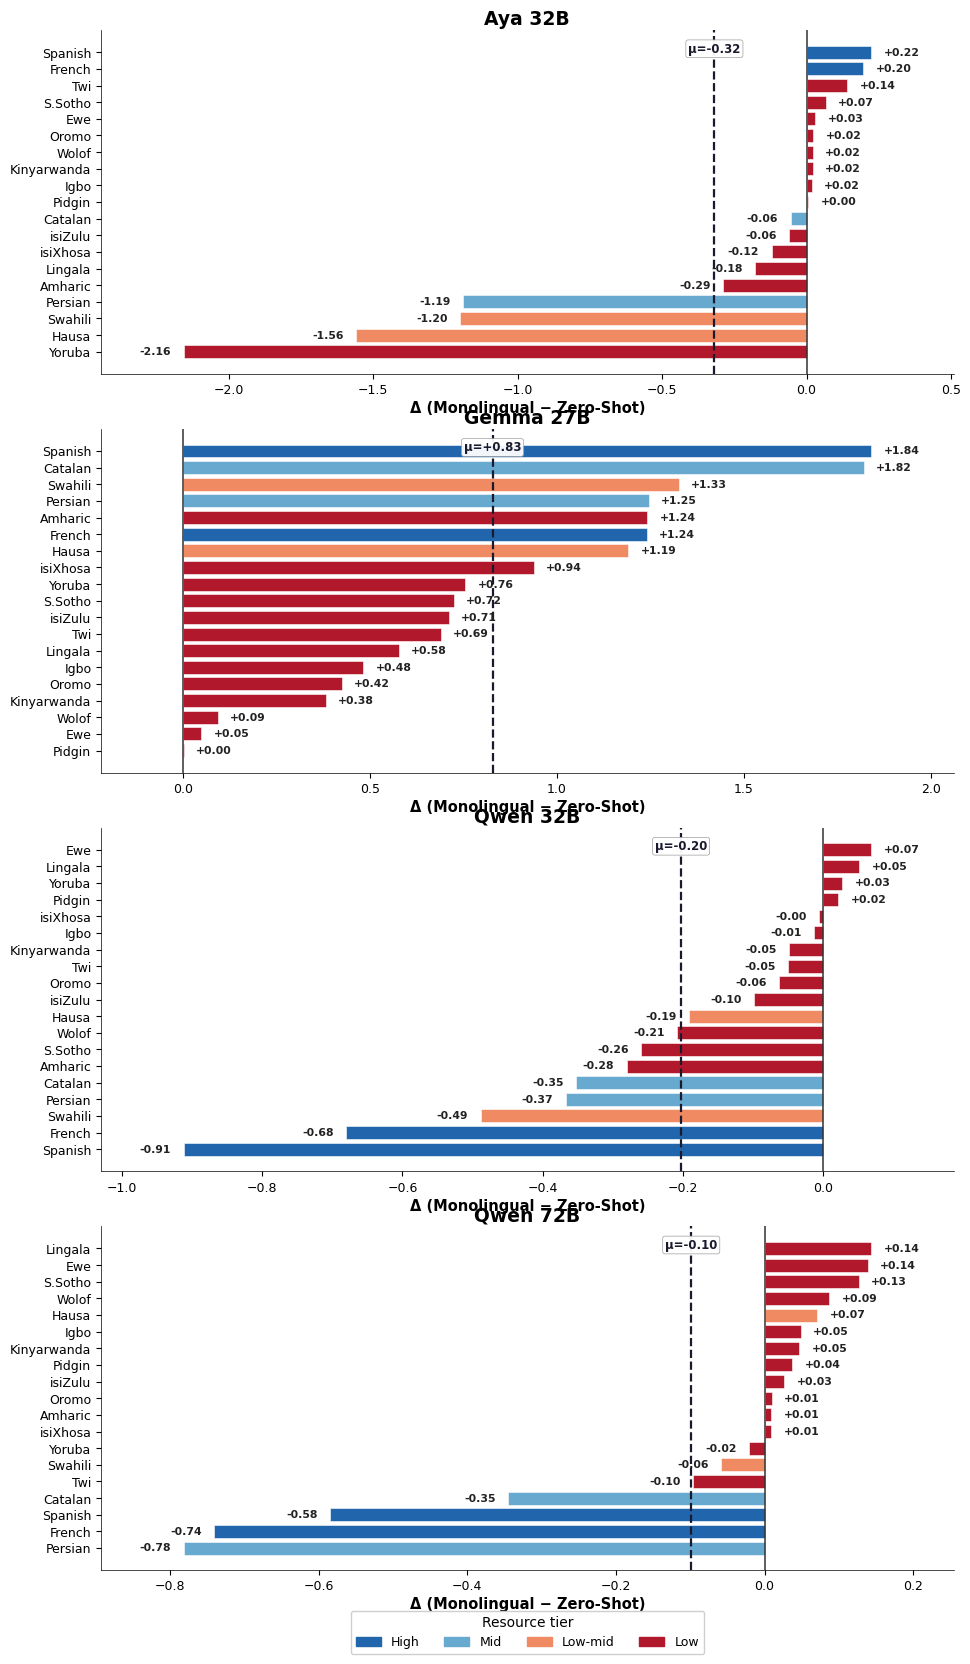

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

SINGLE_TASK_LANGS = ['ara', 'bem', 'deu', 'fon', 'lug', 'som', 'tir', 'eng']

mono_rows = []

for m in models_present:
    msub = df[(df.model == m) & (~df.lang.isin(SINGLE_TASK_LANGS))]

    mono = (
        msub[msub.strategy == 'monolingual']
        .groupby(['lang', 'lang_name', 'resource'])['mean']
        .mean()
        .reset_index()
    )

    zs = (
        msub[msub.strategy == 'zero_shot']
        .groupby('lang')['mean']
        .mean()
        .reset_index()
        .rename(columns={'mean': 'zs'})
    )

    cmp = mono.merge(zs, on='lang')
    cmp['delta'] = cmp['mean'] - cmp['zs']
    cmp['model'] = MODEL_LABELS[m]
    mono_rows.append(cmp)

mono_df = pd.concat(mono_rows, ignore_index=True)

fig, axes = plt.subplots(
    4, 1,
    figsize=(11, 20),
    gridspec_kw={'hspace': 0.16}
)

axes = axes.flatten()

for ax, m in zip(axes, [MODEL_LABELS[x] for x in models_present]):

    sub = (
        mono_df[mono_df.model == m]
        .sort_values('delta')
        .reset_index(drop=True)
    )

    colors = [RES_COLORS[r] for r in sub.resource]

    ax.barh(
        range(len(sub)),
        sub.delta,
        color=colors,
        height=0.78,
        edgecolor='white',
        linewidth=0.4
    )

    xmin = sub.delta.min()
    xmax = sub.delta.max()
    x_range = xmax - xmin

    label_offset = x_range * 0.018
    pad = x_range * 0.12

    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub.lang_name, fontsize=9)

    ax.axvline(0, color='#333333', lw=1.1)

    mean_d = sub.delta.mean()
    ax.axvline(mean_d, color='#1a1a2e', lw=1.6, ls='--')

    ax.text(
        mean_d,
        len(sub) - 0.4,
        f'μ={mean_d:+.2f}',
        fontsize=8.5,
        fontweight='bold',
        ha='center',
        va='top',
        color='#1a1a2e',
        bbox=dict(
            boxstyle='round,pad=0.2',
            fc='white',
            ec='#999999',
            lw=0.5,
            alpha=0.95
        )
    )

    # all values, close to bar ends
    for i, row in sub.iterrows():

        if row.delta >= 0:
            x = row.delta + label_offset
            ha = 'left'
        else:
            x = row.delta - label_offset
            ha = 'right'

        ax.text(
            x,
            i,
            f'{row.delta:+.2f}',
            fontsize=7.8,
            fontweight='bold',
            ha=ha,
            va='center',
            color='#222222'
        )

    ax.set_title(m, fontsize=13.5, fontweight='bold', pad=4)

    ax.set_xlabel(
        'Δ (Monolingual − Zero-Shot)',
        fontsize=10.5,
        fontweight='bold',
        labelpad=3
    )

    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

handles = [
    mpatches.Patch(color=RES_COLORS[r], label=r.capitalize())
    for r in RES_ORDER
]

axes[-1].legend(
    handles=handles,
    title='Resource tier',
    title_fontsize=10,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(RES_ORDER),
    framealpha=0.95,
    edgecolor='#cccccc'
)

plt.tight_layout()

plt.savefig(
    FIGDIR / 'rq3_monolingual_effect_final.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

### Table 6 — English–low-resource scoring gap

In [12]:
# Exclude single-task languages (keep English as baseline)
data_gap = df[~df['lang'].isin(SINGLE_TASK_LANGS)]

tasks_gap = ['MT', 'Sum', 'QA', 'Math']
print('English - Low-resource scoring gap (Δ = English mean - Low-resource mean)\n')
print(f'{"Strategy":12}' +
      ''.join(f'{t:>8}' for t in tasks_gap) +
      f'{"MT-noSSA":>10} {"Overall":>9}')

for s in STRAT_ORDER:
    ssub = data_gap[data_gap.strategy == s]
    vals, overall_vals = [], []
    for task in tasks_gap:
        t   = ssub[ssub.task == task]
        eng = t[t.lang == 'eng']['mean'].mean()
        low = t[t.resource == 'low']['mean'].mean()
        if np.isnan(eng) or np.isnan(low):
            vals.append('NaN')
        else:
            g = eng - low
            vals.append(f'{g:+.3f}')
            overall_vals.append(g)

    # MT without SSA-MTE
    t_no = ssub[(ssub.task == 'MT') & (ssub.dataset != 'ssa_mte')]
    eng2 = t_no[t_no.lang == 'eng']['mean'].mean()
    low2 = t_no[t_no.resource == 'low']['mean'].mean()
    mt_no = f'{eng2-low2:+.3f}' if not (np.isnan(eng2) or np.isnan(low2)) else 'NaN'

    ov = f'{np.mean(overall_vals):+.3f}' if overall_vals else 'NaN'
    print(f'{STRAT_LABELS.get(s,s):12}' +
          ''.join(f'{v:>8}' for v in vals) +
          f'{mt_no:>10} {ov:>9}')

English - Low-resource scoring gap (Δ = English mean - Low-resource mean)

Strategy          MT     Sum      QA    Math  MT-noSSA   Overall
Zero-Shot        NaN     NaN     NaN     NaN       NaN       NaN
Few-Shot         NaN     NaN     NaN     NaN       NaN       NaN
Prometheus       NaN     NaN     NaN     NaN       NaN       NaN
CoT              NaN     NaN     NaN     NaN       NaN       NaN
Cross-Ling.      NaN     NaN     NaN     NaN       NaN       NaN
Monolingual      NaN     NaN     NaN     NaN       NaN       NaN
Trans-Eval       NaN     NaN     NaN     NaN       NaN       NaN
Role             NaN     NaN     NaN     NaN       NaN       NaN
Self-Cons.       NaN     NaN     NaN     NaN       NaN       NaN


---
## 5. SRQ4 — External Validity

### Table 7 — Spearman ρ vs human annotations (SSA-MTE)

In [13]:
ssa = df[(df.dataset == 'ssa_mte') & (df.human_score_mean.notna())]

print('Per-example Spearman ρ (judge score vs human score) — SSA-MTE\n')
print(f'{"Strategy":12}' +
      ''.join(f'{MODEL_LABELS[m]:>10}' for m in models_present) +
      f'{"Mean":>10}')

strats_ssa = [s for s in STRAT_ORDER if s in ssa.strategy.unique()]
rows = []
for s in strats_ssa:
    ssub = ssa[ssa.strategy == s]
    rhos = []
    for m in models_present:
        msub = ssub[ssub.model == m]
        if len(msub) >= 3:
            rho, p = spearmanr(msub['mean'], msub['human_score_mean'])
            rhos.append(rho)
        else:
            rhos.append(np.nan)
    mean_rho = np.nanmean(rhos)
    rows.append((STRAT_LABELS.get(s, s), rhos, mean_rho))

rows.sort(key=lambda r: -r[2])
for name, rhos, mean_rho in rows:
    row = f'{name:12}'
    for v in rhos:
        row += f'{v:>10.3f}' if not np.isnan(v) else f'{"---":>10}'
    row += f'{mean_rho:>10.3f}'
    print(row)

Per-example Spearman ρ (judge score vs human score) — SSA-MTE

Strategy       Aya 32B Gemma 27B  Qwen 32B  Qwen 72B      Mean
Trans-Eval       0.173    -0.073     0.114     0.296     0.127
Monolingual      0.173     0.141     0.014     0.032     0.090
Cross-Ling.     -0.005     0.027     0.014     0.032     0.017
Role             0.059    -0.014    -0.041    -0.118    -0.028
Prometheus       0.105     0.109    -0.187    -0.282    -0.064
Few-Shot         0.073    -0.036    -0.187    -0.269    -0.105
Zero-Shot       -0.100    -0.109    -0.187    -0.465    -0.215


## Appendix Per-Model Strategy × Dataset Heatmaps 


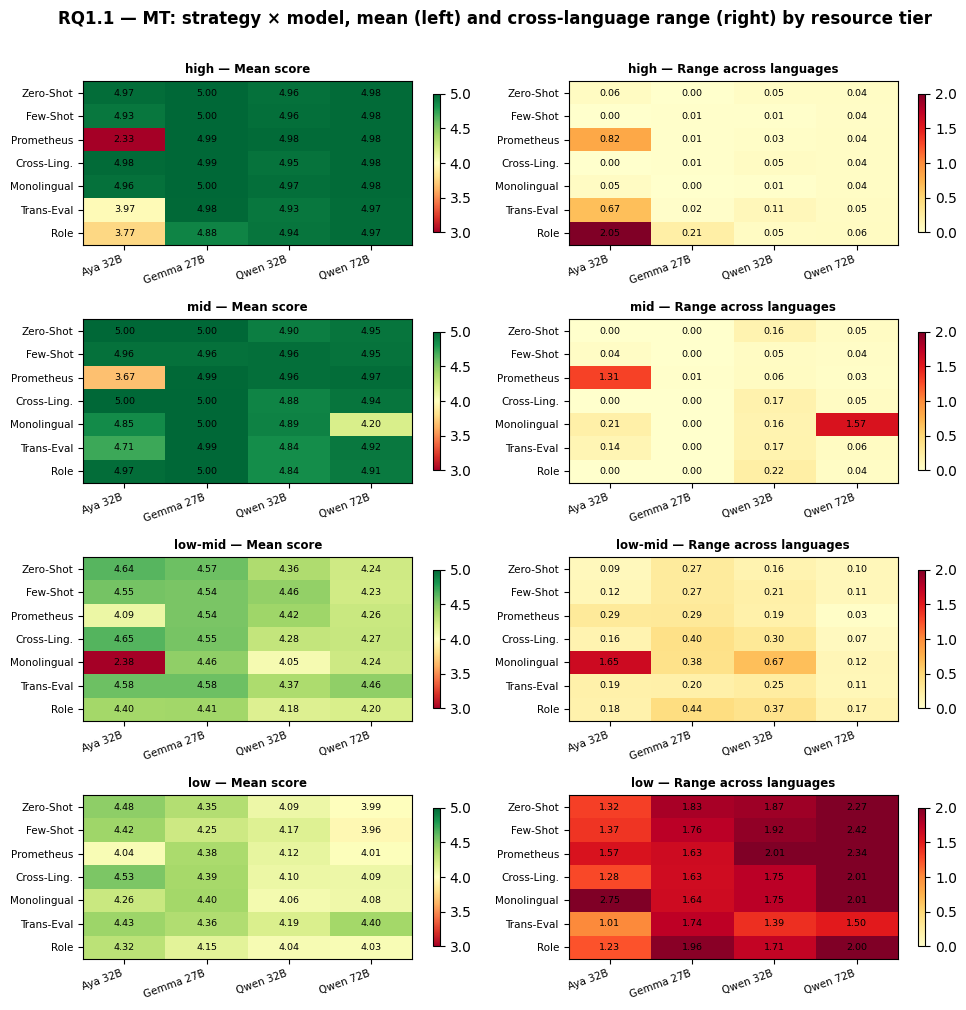

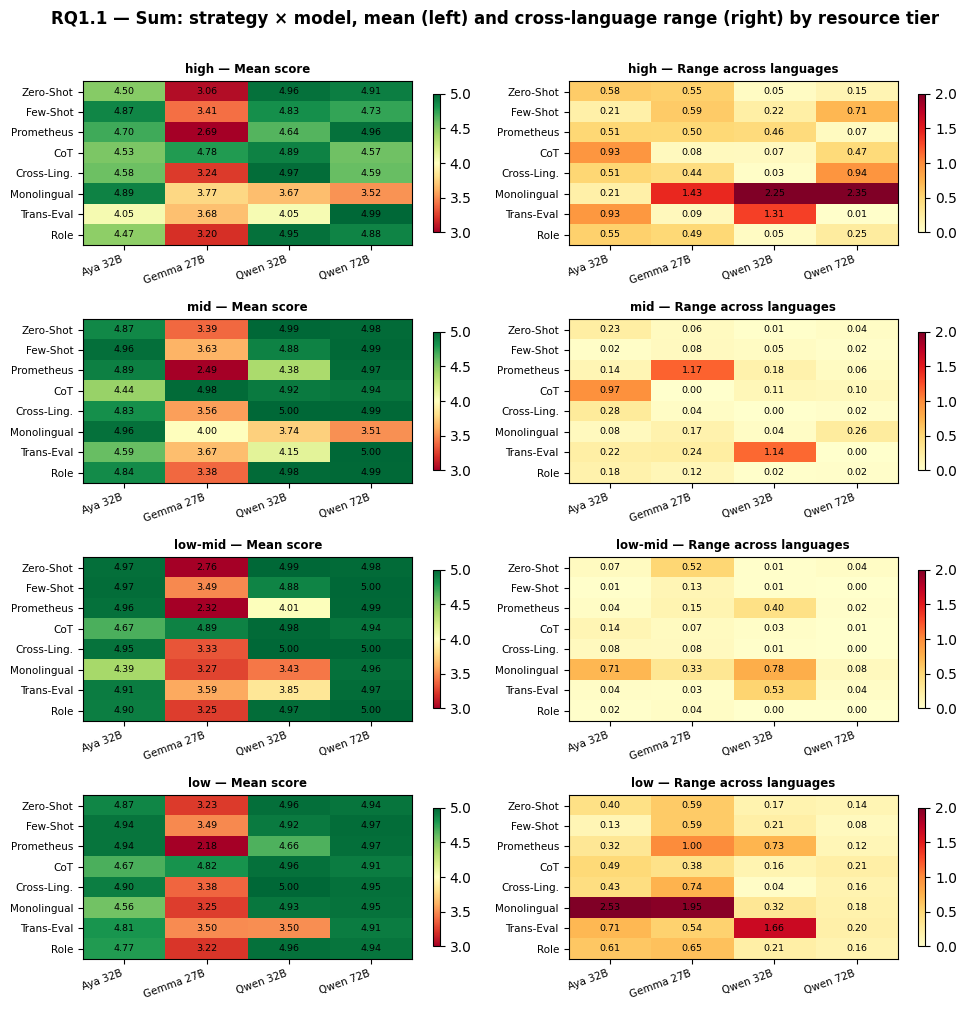

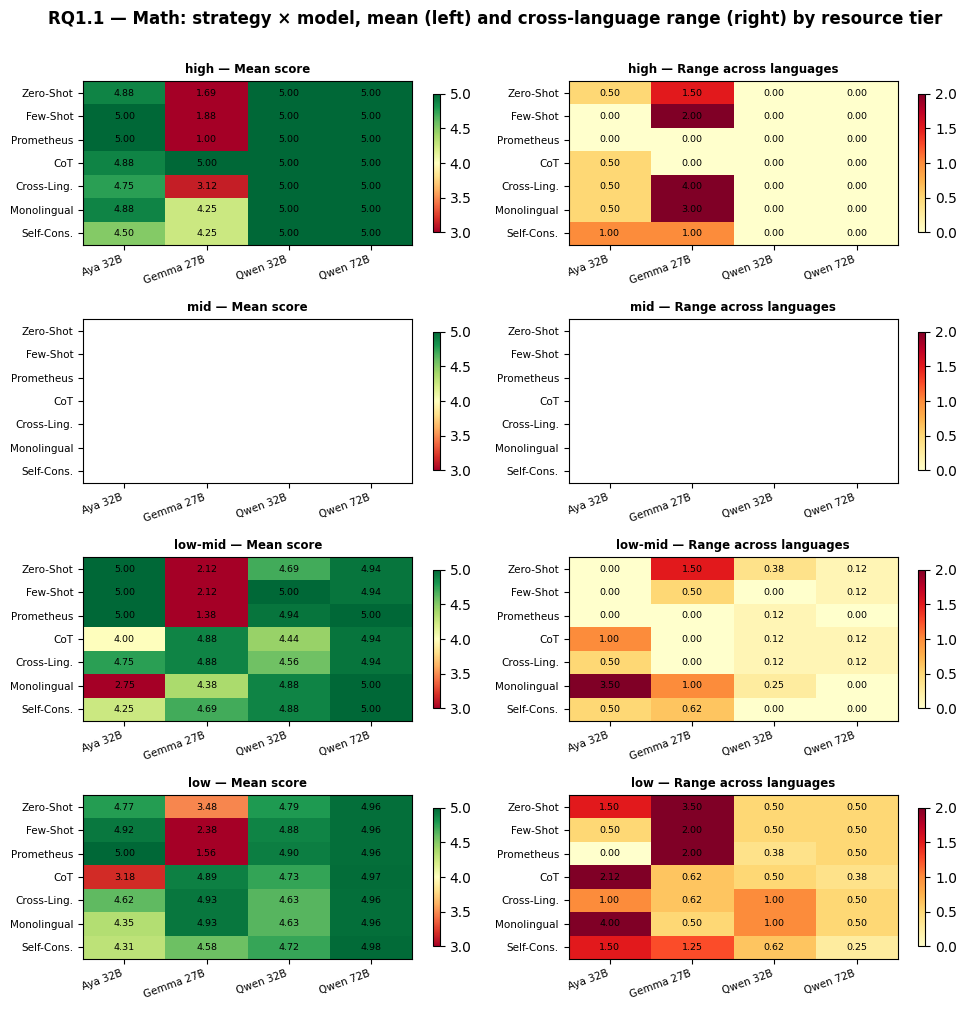

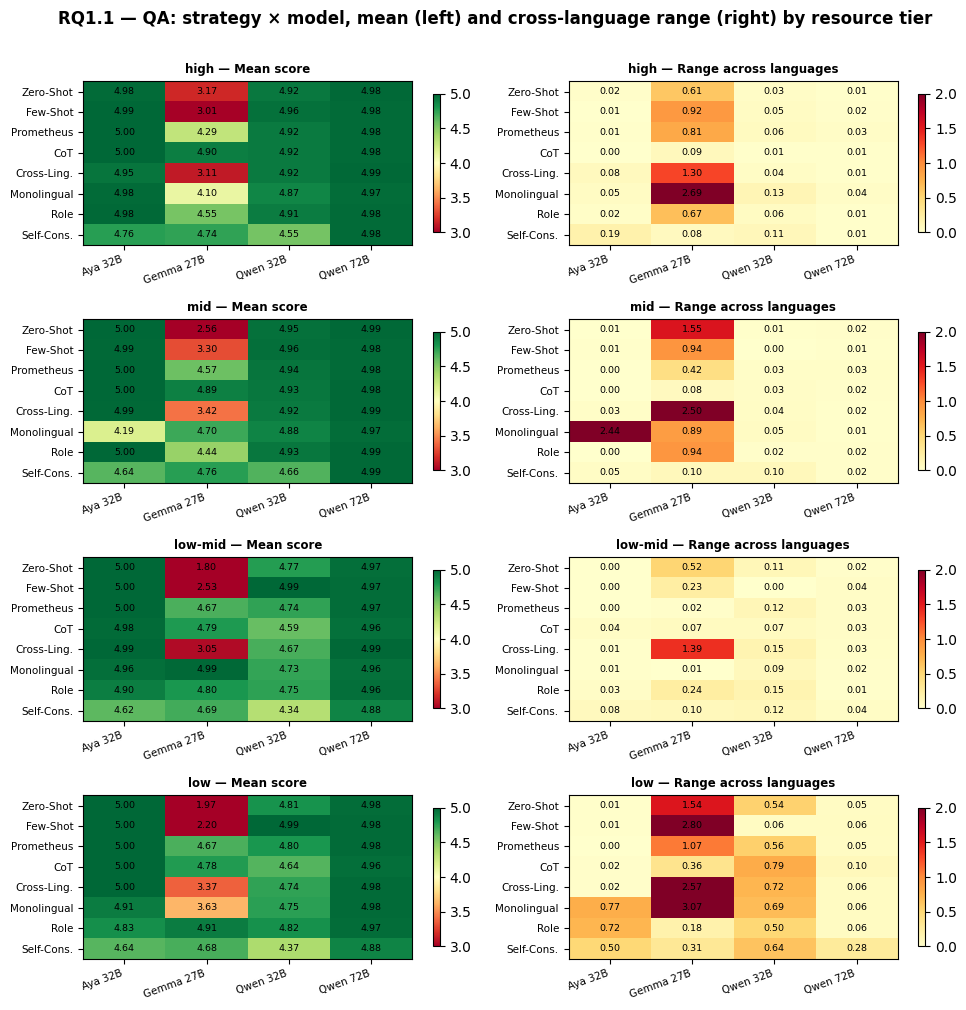

In [14]:
def lang_mean_range(cell):
    lm = cell.groupby('lang')['mean'].mean()
    return (lm.mean(), (lm.max()-lm.min()) if len(lm)>=2 else np.nan, len(lm))

for task in ['MT','Sum','Math', 'QA']:   
    task_sub = df[df.task==task]
    strats_task = [s for s in STRAT_ORDER if s in task_sub.strategy.unique()]
    yl = [STRAT_LABELS[s] for s in strats_task]
    fig, axes = plt.subplots(len(RES_ORDER), 2, figsize=(10, 2.5*len(RES_ORDER)))
    for ri, rc in enumerate(RES_ORDER):
        sub = task_sub[task_sub.resource==rc]
        for ci,(metric,label,vmin,vmax,cmap) in enumerate([
                ('mean','Mean score',3.0,5.0,'RdYlGn'),
                ('range','Range across languages',0.0,2.0,'YlOrRd')]):
            ax = axes[ri,ci]
            mat = pd.DataFrame(index=yl, columns=[MODEL_LABELS[m] for m in models_present], dtype=float)
            for s in strats_task:
                for m in models_present:
                    mu, rg, nlang = lang_mean_range(sub[(sub.strategy==s)&(sub.model==m)])
                    mat.loc[STRAT_LABELS[s], MODEL_LABELS[m]] = mu if metric=='mean' else rg
            im = ax.imshow(mat.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
            ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=20, ha='right', fontsize=7.5)
            ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=7.5)
            for r in range(mat.shape[0]):
                for c in range(mat.shape[1]):
                    v = mat.values[r,c]
                    if not np.isnan(v):
                        ax.text(c,r,f'{v:.2f}',ha='center',va='center',fontsize=6.8,
                                color='black' if vmin+0.2*(vmax-vmin)<v<vmin+0.8*(vmax-vmin) else 'black')
            ax.set_title(f'{rc} — {label}', fontsize=8.5, fontweight='bold')
            plt.colorbar(im, ax=ax, shrink=0.85)
    fig.suptitle(f'RQ1.1 — {task}: strategy × model, mean (left) and cross-language range (right) by resource tier',
                 fontweight='bold', y=1.005)
    plt.tight_layout(); plt.savefig(FIGDIR/f'rq1_mean_range_{task.lower()}.png'); plt.show()


## Appendix  Rubric Dimension Analysis

### Figure A5 — Mean rubric dimension scores per strategy and task

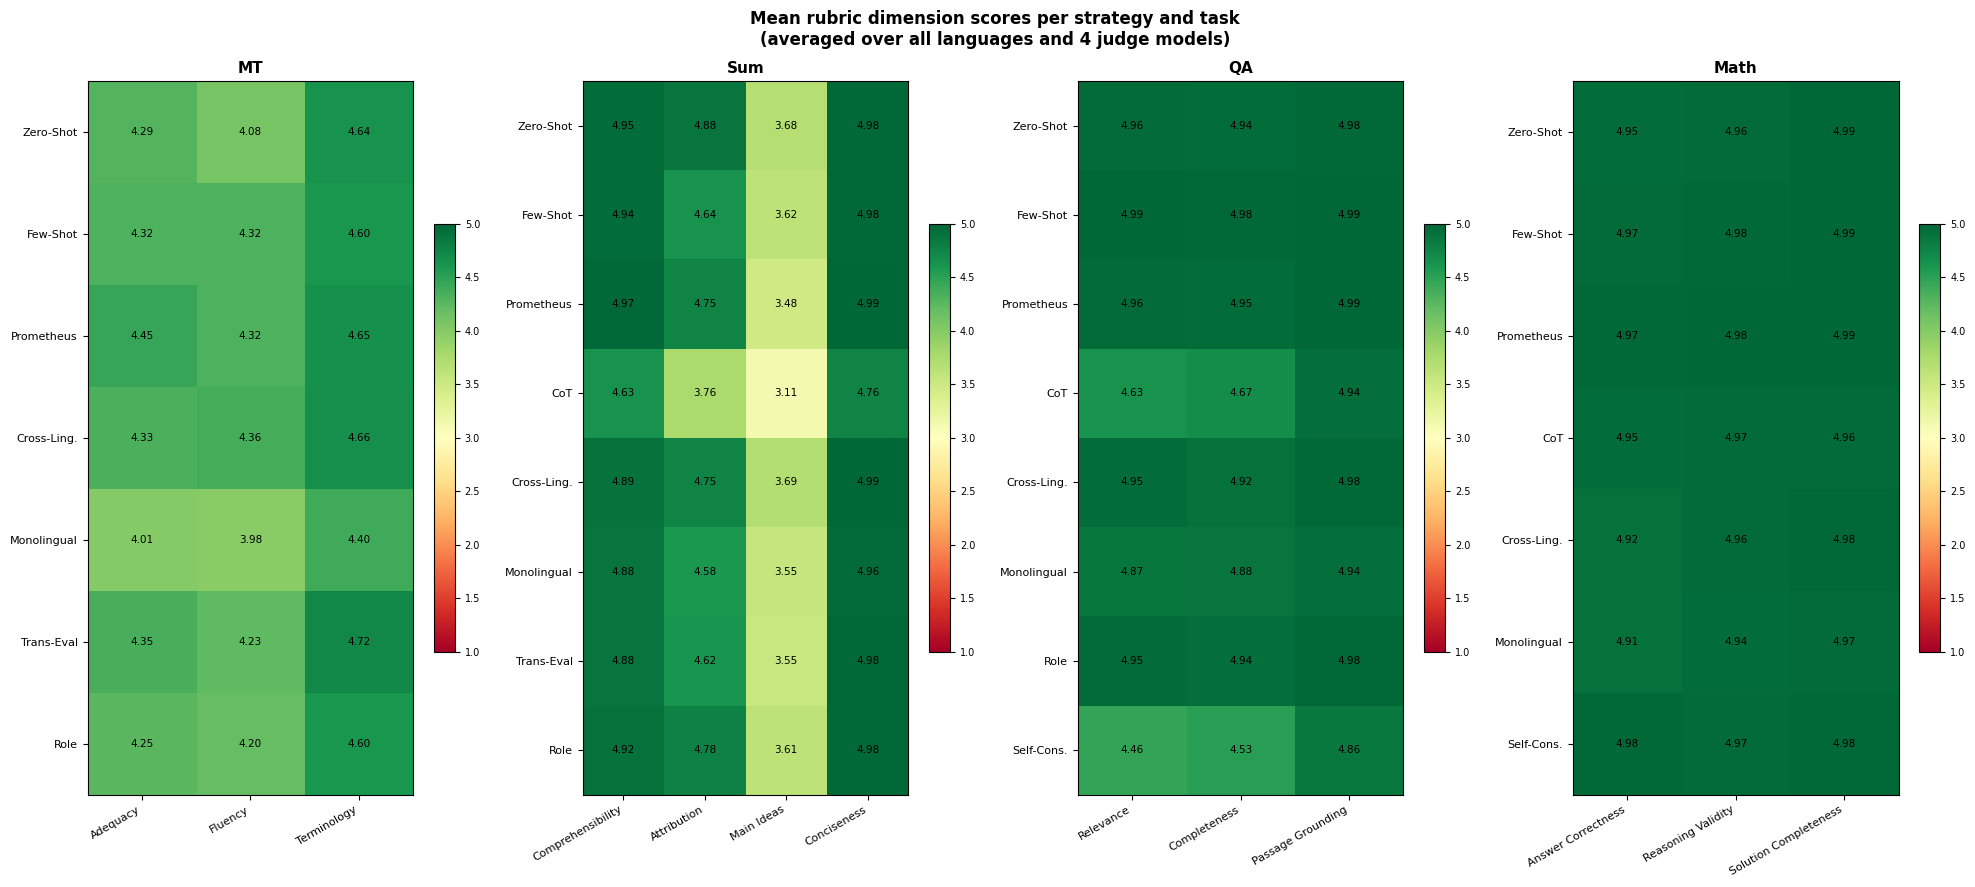

Saved: rubric_overview.png


In [15]:
RUBRIC_DIMS = {
    'MT':  ['dim_adequacy', 'dim_fluency', 'dim_terminology'],
    'Sum': ['dim_comprehensibility', 'dim_attribution', 'dim_main_ideas', 'dim_conciseness'],
    'QA':  ['dim_relevance', 'dim_completeness', 'dim_passage_grounding'],
    'Math':['dim_answer_correctness', 'dim_reasoning_validity', 'dim_solution_completeness'],
}
DIM_LABELS = {
    'dim_adequacy':              'Adequacy',
    'dim_fluency':               'Fluency',
    'dim_terminology':           'Terminology',
    'dim_comprehensibility':     'Comprehensibility',
    'dim_attribution':           'Attribution',
    'dim_main_ideas':            'Main Ideas',
    'dim_conciseness':           'Conciseness',
    'dim_relevance':             'Relevance',
    'dim_completeness':          'Completeness',
    'dim_passage_grounding':     'Passage Grounding',
    'dim_answer_correctness':    'Answer Correctness',
    'dim_reasoning_validity':    'Reasoning Validity',
    'dim_solution_completeness': 'Solution Completeness',
}

tasks_rubric = ['MT', 'Sum', 'QA', 'Math']
n_tasks = len(tasks_rubric)
fig, axes = plt.subplots(1, n_tasks, figsize=(5 * n_tasks, 9))

for ax, task in zip(axes, tasks_rubric):
    dims     = RUBRIC_DIMS[task]
    task_sub = df[df.task == task]
    strats   = [s for s in STRAT_ORDER if s in task_sub.strategy.unique()]

    mat = pd.DataFrame(index=[STRAT_LABELS[s] for s in strats],
                       columns=[DIM_LABELS[d] for d in dims], dtype=float)
    for s in strats:
        ssub = task_sub[task_sub.strategy == s]
        for d in dims:
            if d in ssub.columns:
                mat.loc[STRAT_LABELS[s], DIM_LABELS[d]] = ssub[d].mean()

    im = ax.imshow(mat.values.astype(float), cmap='RdYlGn',
                   vmin=1, vmax=5, aspect='auto')
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_title(task, fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.6).ax.tick_params(labelsize=7)

    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                        fontsize=7.5, color='white' if v < 2.5 else 'black')

fig.suptitle('Mean rubric dimension scores per strategy and task\n'
             '(averaged over all languages and 4 judge models)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGDIR / 'rubric_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: rubric_overview.png')

### Figures A6–A7 — Rubric dimensions by resource tier (MT + Sum)

Saved: mt_rub.png
Saved: sum_rub.png


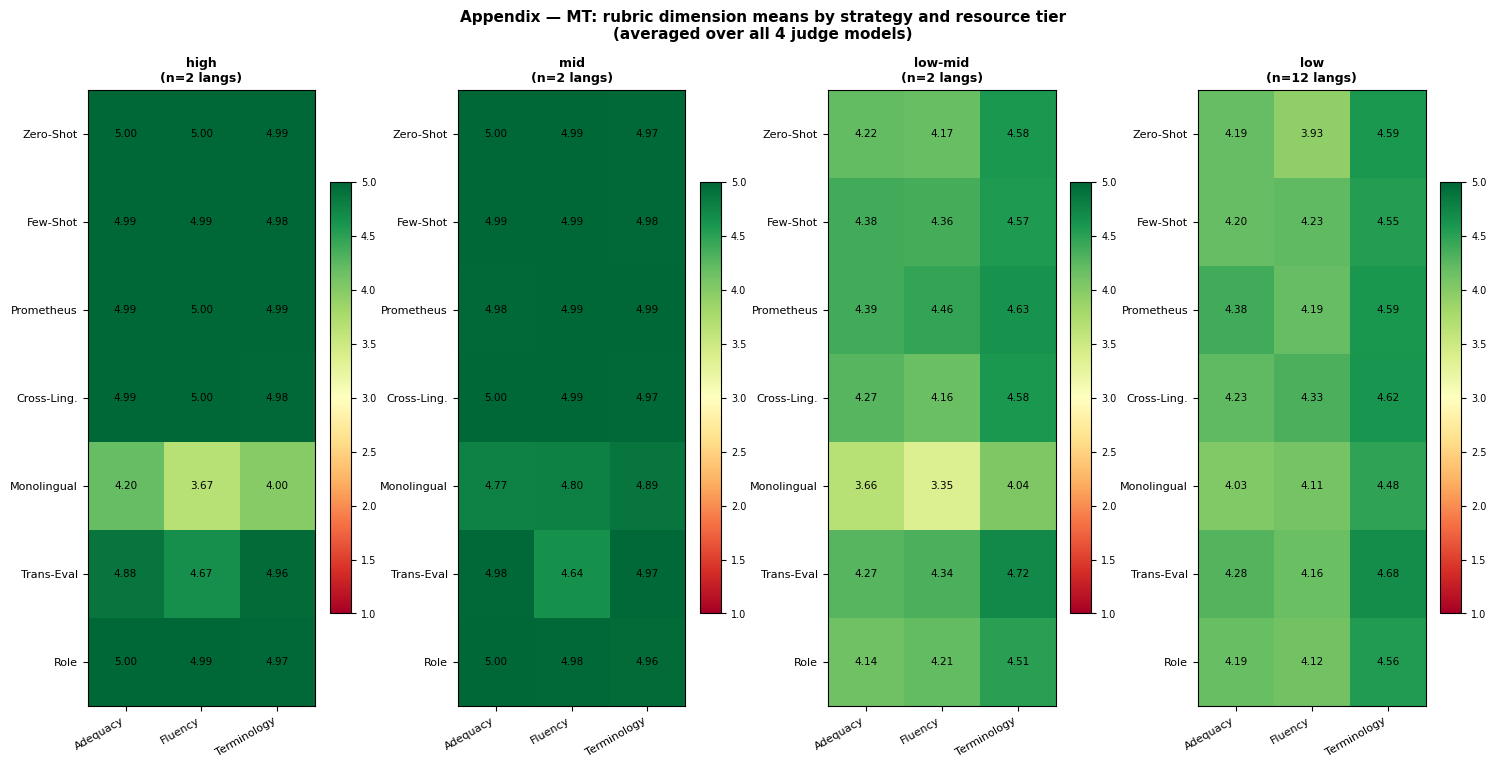

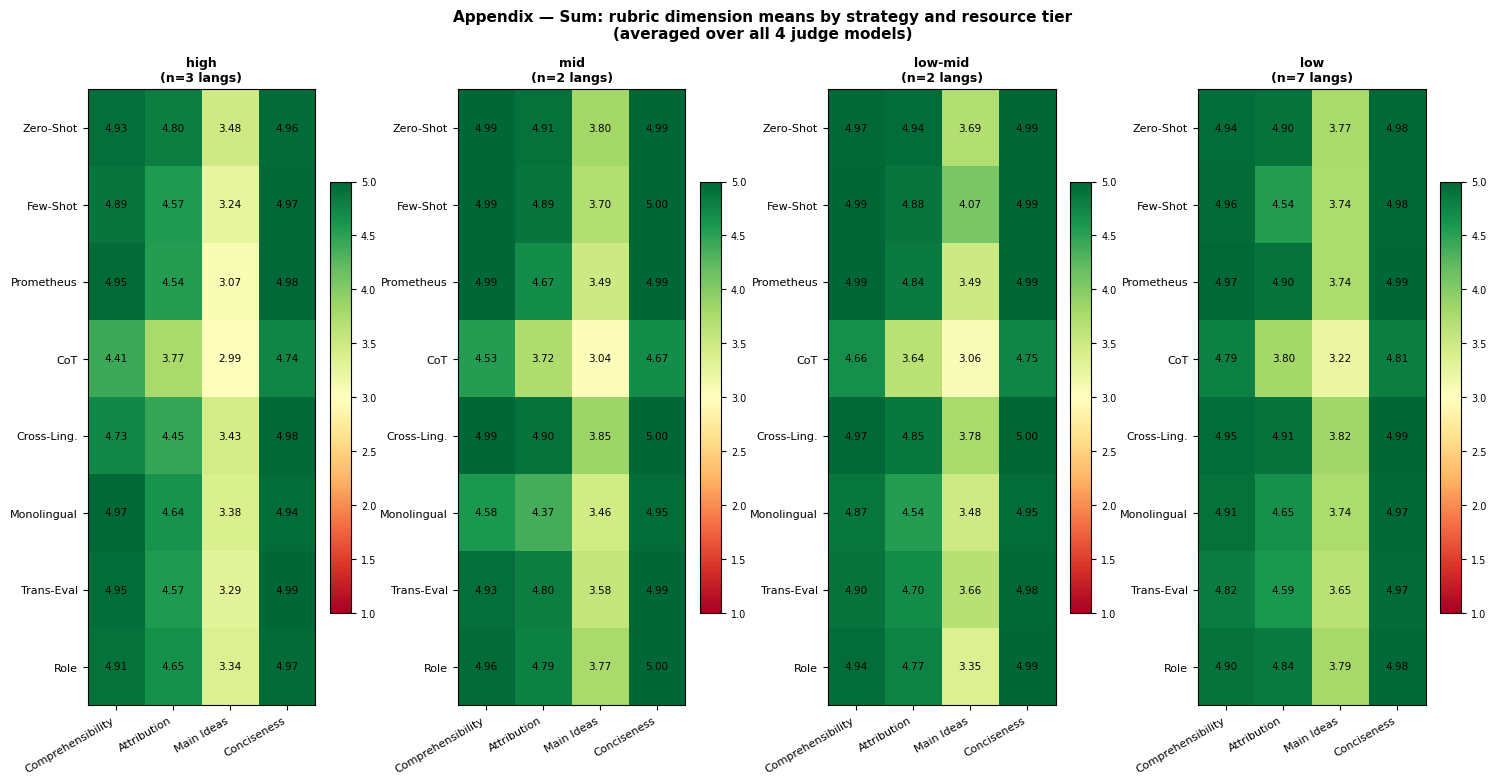

In [16]:
for task, dims, fname in [
    ('MT',  ['dim_adequacy','dim_fluency','dim_terminology'], 'mt_rub'),
    ('Sum', ['dim_comprehensibility','dim_attribution','dim_main_ideas','dim_conciseness'], 'sum_rub'),
]:
    task_sub    = df[df.task == task]
    strats      = [s for s in STRAT_ORDER if s in task_sub.strategy.unique()]
    res_present = [r for r in RES_ORDER if len(task_sub[task_sub.resource == r]) > 0]

    fig, axes = plt.subplots(1, len(res_present),
                             figsize=(4.5 * len(res_present), 8),
                             gridspec_kw={'wspace': 0.3})
    if len(res_present) == 1:
        axes = [axes]

    for ax, rc in zip(axes, res_present):
        sub = task_sub[task_sub.resource == rc]
        mat = pd.DataFrame(
            index=[STRAT_LABELS[s] for s in strats],
            columns=[DIM_LABELS[d] for d in dims], dtype=float
        )
        for s in strats:
            ssub = sub[sub.strategy == s]
            for d in dims:
                if d in ssub.columns:
                    mat.loc[STRAT_LABELS[s], DIM_LABELS[d]] = ssub[d].mean()

        n_langs = sub['lang'].nunique()
        im = ax.imshow(mat.values.astype(float), cmap='RdYlGn',
                       vmin=1, vmax=5, aspect='auto')
        ax.set_xticks(range(mat.shape[1]))
        ax.set_xticklabels(mat.columns, rotation=30, ha='right', fontsize=8)
        ax.set_yticks(range(mat.shape[0]))
        ax.set_yticklabels(mat.index, fontsize=8)
        ax.set_title(f'{rc}\n(n={n_langs} langs)', fontweight='bold', fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.7).ax.tick_params(labelsize=7)

        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                v = mat.values[r, c]
                if not np.isnan(v):
                    ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                            fontsize=7.5, color='black')

    fig.suptitle(f'Appendix — {task}: rubric dimension means by strategy and resource tier\n'
                 '(averaged over all 4 judge models)',
                 fontweight='bold', fontsize=11)
    plt.savefig(FIGDIR / f'{fname}.png', dpi=300, bbox_inches='tight')
    print(f'Saved: {fname}.png')

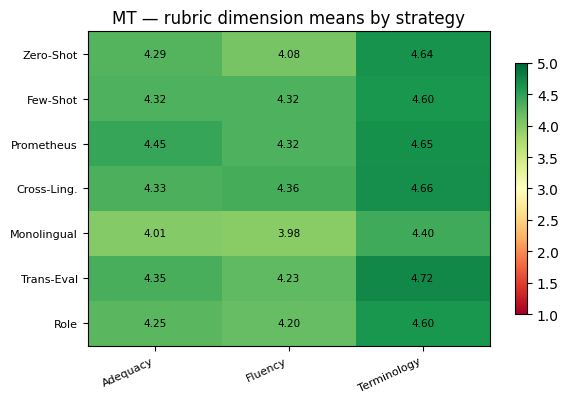

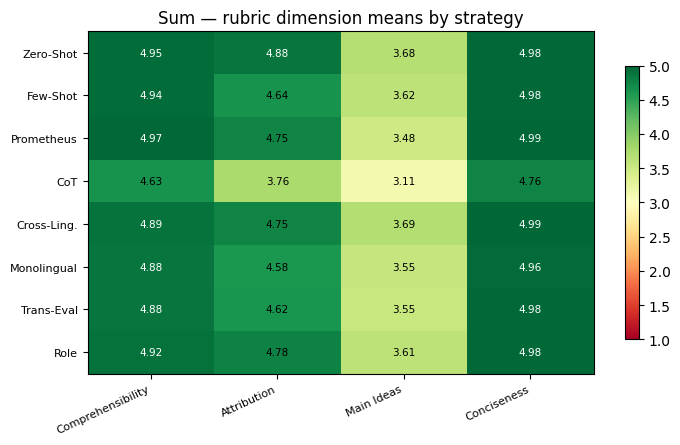

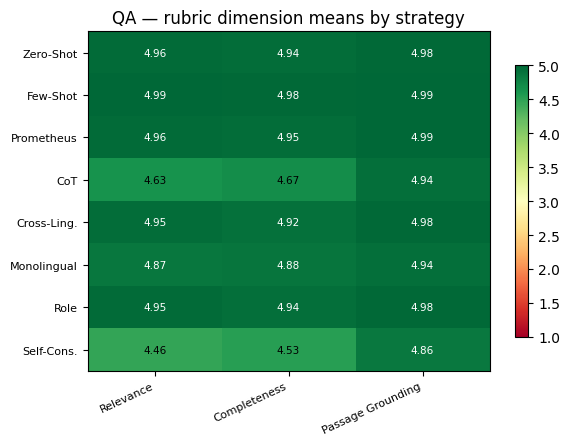

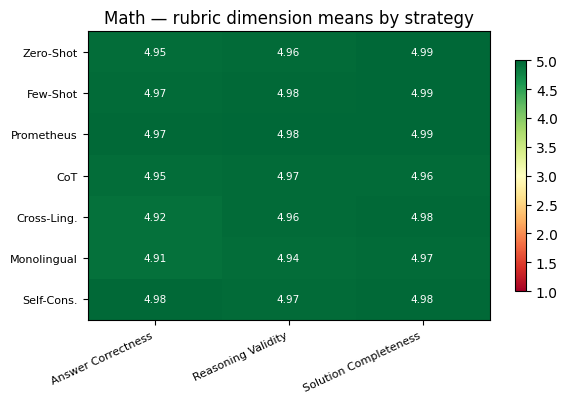

Passage Grounding coverage (should be NaN for afriqa only):
dataset
afriqa       0.00
belebele     0.98
catalanqa    0.91
persianqa    0.94
xquad        0.97


In [17]:
# Rubric dimensions per task
TASK_DIMS = {
    'MT':  ['dim_adequacy','dim_fluency','dim_terminology'],
    'Sum': ['dim_comprehensibility','dim_attribution','dim_main_ideas','dim_conciseness'],
    'QA':  ['dim_relevance','dim_completeness','dim_passage_grounding'],
    'Math':['dim_answer_correctness','dim_reasoning_validity','dim_solution_completeness'],
}
DIM_LABELS = {c: c.replace('dim_','').replace('_',' ').title() for cols in TASK_DIMS.values() for c in cols}

for task, dims in TASK_DIMS.items():
    sub = df[df.task==task]
    strats = [s for s in STRAT_ORDER if s in sub.strategy.unique()]
    mat = pd.DataFrame(index=[STRAT_LABELS[s] for s in strats],
                       columns=[DIM_LABELS[d] for d in dims], dtype=float)
    for s in strats:
        for d in dims:
            mat.loc[STRAT_LABELS[s], DIM_LABELS[d]] = sub[sub.strategy==s][d].mean()
    fig, ax = plt.subplots(figsize=(1.3*len(dims)+2.2, 0.42*len(strats)+1.2))
    im = ax.imshow(mat.values.astype(float), cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=25, ha='right', fontsize=8)
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=8)
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            v = mat.values[r,c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                        color='black' if 2.2<v<4.8 else 'white')
    ax.set_title(f'{task} — rubric dimension means by strategy')
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.savefig(FIGDIR/f'rubric_{task.lower()}_dims.png'); plt.show()

# QA note: passage grounding only exists for passage datasets (afriqa excluded by design)
qa = df[df.task=='QA']
print('Passage Grounding coverage (should be NaN for afriqa only):')
print(qa.groupby('dataset')['dim_passage_grounding'].apply(lambda s: s.notna().mean()).round(2).to_string())

## Appendix Intermodal Agreement 


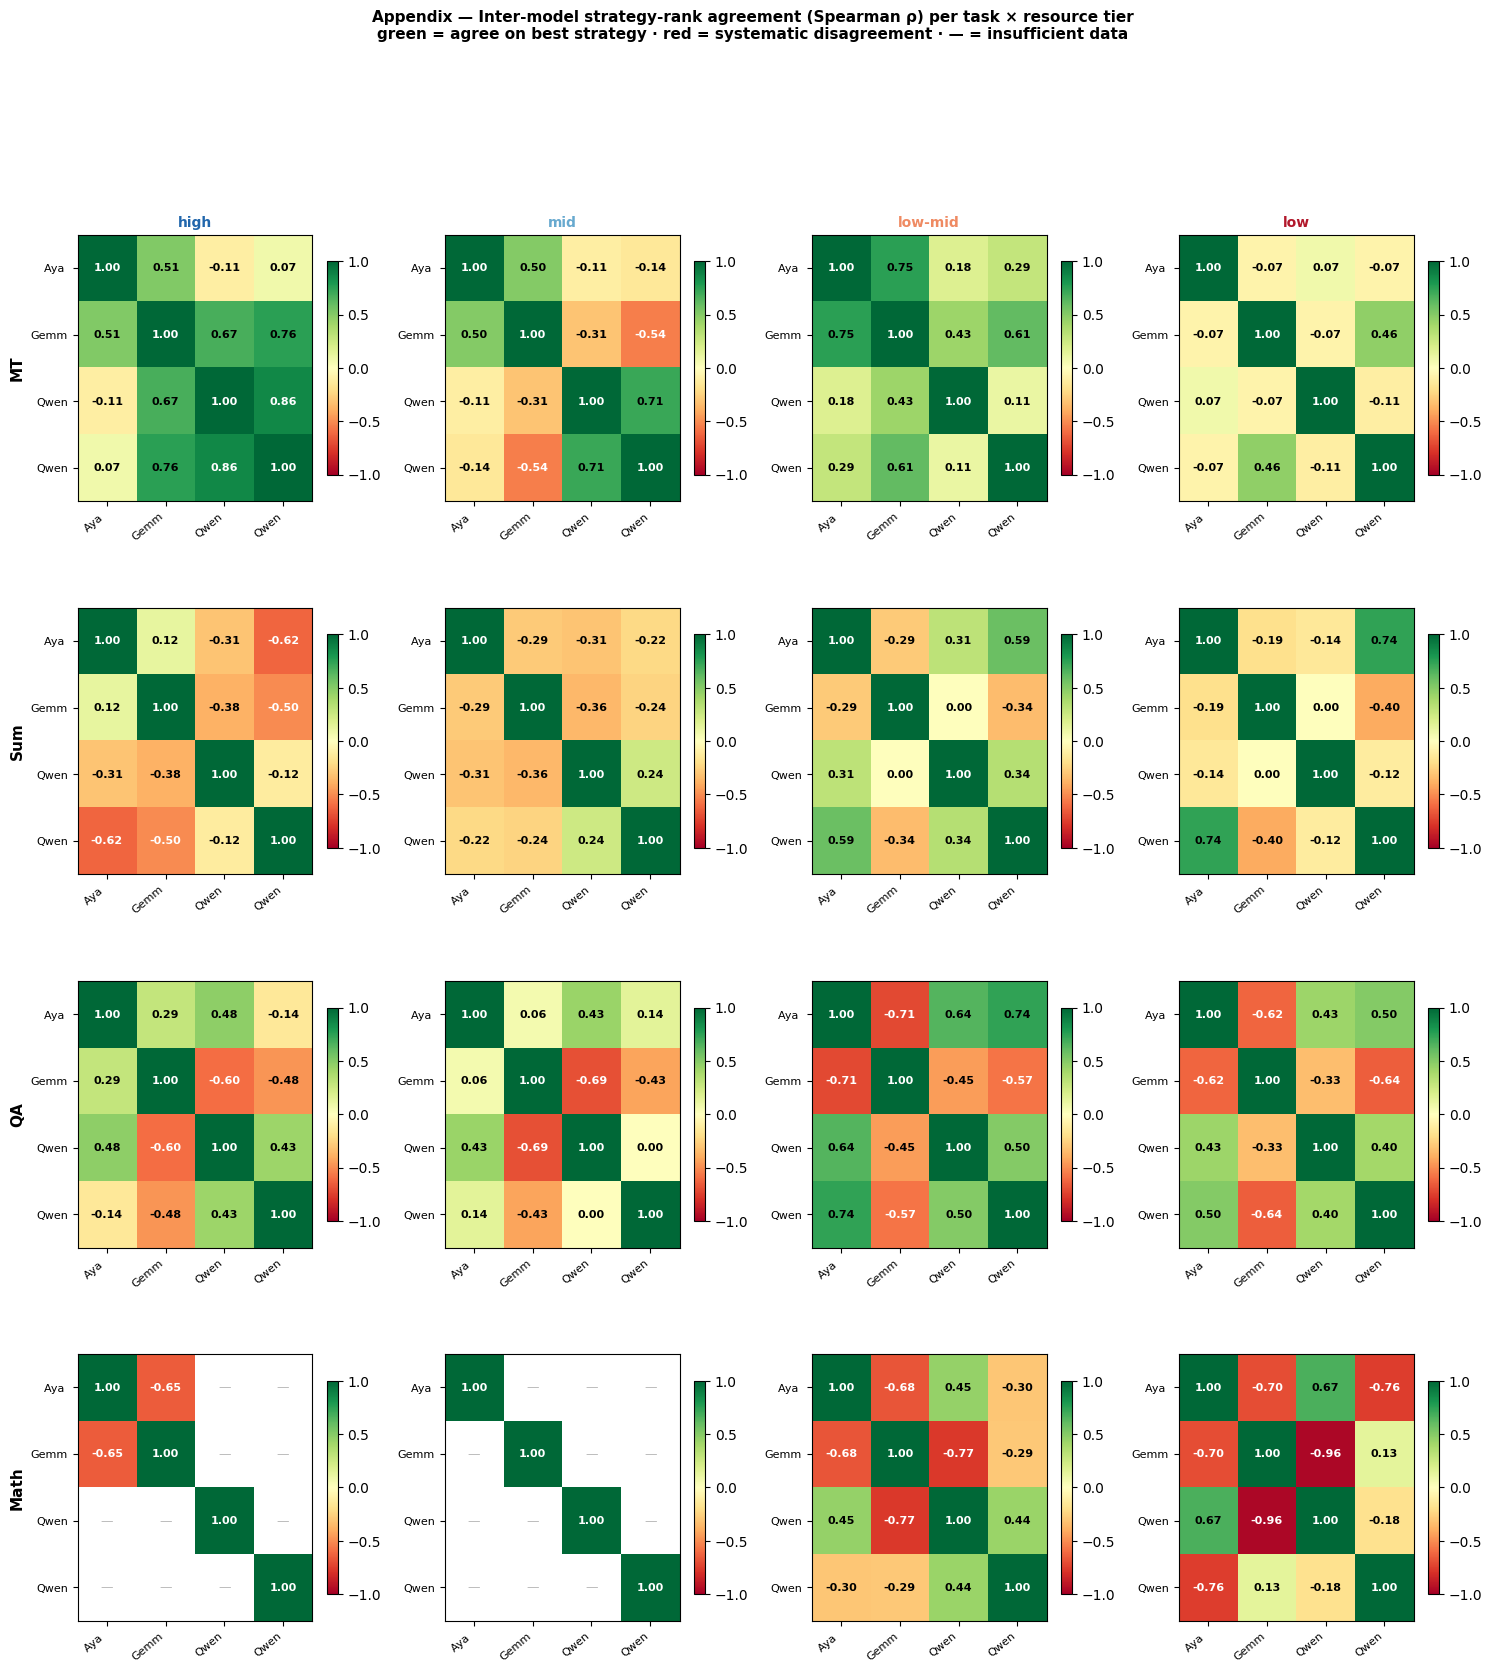

In [18]:
# ══════════════════════════════════════════════════════════════
# APPENDIX FIG 1 — Full inter-model Spearman rank agreement
# All tasks × resource tiers (4×4 matrix per cell)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(
    len(TASK_ORDER), len(RES_ORDER),
    figsize=(4.5*len(RES_ORDER), 4.5*len(TASK_ORDER)),
    gridspec_kw={'hspace':0.4, 'wspace':0.25}
)

for ri, task in enumerate(TASK_ORDER):
    ts = df[df.task==task]
    st = [s for s in STRAT_ORDER if s in ts.strategy.unique()]
    for ci, rc in enumerate(RES_ORDER):
        ax = axes[ri, ci]
        sub = ts[ts.resource==rc]
        labels = [MODEL_LABELS[m][:4] for m in models_present]
        mat = np.full((len(models_present), len(models_present)), np.nan)
        np.fill_diagonal(mat, 1.0)
        for m1, m2 in combinations(models_present, 2):
            v1=[sub[(sub.model==m1)&(sub.strategy==s)]['mean'].mean() for s in st]
            v2=[sub[(sub.model==m2)&(sub.strategy==s)]['mean'].mean() for s in st]
            pair=[(a,b) for a,b in zip(v1,v2) if not(np.isnan(a) or np.isnan(b))]
            if len(pair)>=4:
                rho,_=spearmanr([p[0] for p in pair],[p[1] for p in pair])
                i,j=models_present.index(m1),models_present.index(m2)
                mat[i,j]=mat[j,i]=rho

        im = ax.imshow(mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)

        for r in range(len(models_present)):
            for c in range(len(models_present)):
                v = mat[r,c]
                if not np.isnan(v):
                    col = 'black' if -0.5<v<0.8 else 'white'
                    ax.text(c,r,f'{v:.2f}',ha='center',va='center',
                            fontsize=8,color=col,fontweight='bold')
                else:
                    ax.text(c,r,'—',ha='center',va='center',fontsize=9,color='#bbb')

        if ri==0: ax.set_title(rc, fontsize=10, fontweight='bold', color=RES_COLORS[rc])
        if ci==0: ax.set_ylabel(task, fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(
    'Appendix — Inter-model strategy-rank agreement (Spearman ρ) per task × resource tier\n'
    'green = agree on best strategy · red = systematic disagreement · — = insufficient data',
    fontweight='bold', y=1.005, fontsize=11
)
plt.savefig(FIGDIR/'appendix_intermodel_rank_full.png', bbox_inches='tight', dpi=300)
plt.show()


## Appendix External Validation

Loaded validation_correlation.csv


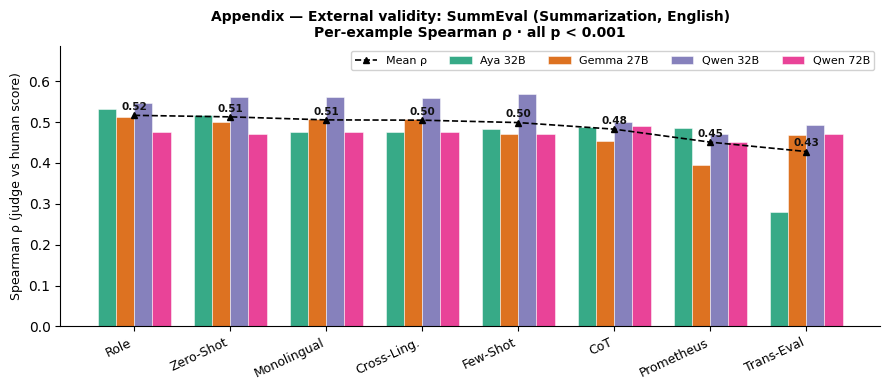

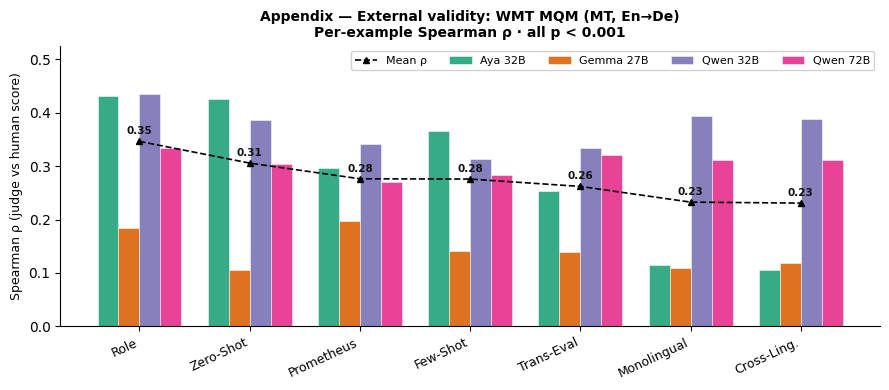

In [19]:


# ══════════════════════════════════════════════════════════════
# APPENDIX External validity: SummEval and WMT MQM
# ══════════════════════════════════════════════════════════════

try:
    val = pd.read_csv('validation_correlation.csv')
    val = val.rename(columns={c:c.lower() for c in val.columns})
    print('Loaded validation_correlation.csv')
except FileNotFoundError:
    # Fallback recorded values
    
    print('no results')

for ds, ds_label, task_label in [
    ('summeval', 'SummEval', 'Summarization, English'),
    ('wmt_mqm',  'WMT MQM',  'MT, En→De'),
]:
    sub = val[val.dataset==ds].copy()
    if sub.empty: continue

    order = sub.groupby('strategy').rho.mean().sort_values(ascending=False).index.tolist()
    fig, ax = plt.subplots(figsize=(9, 4.0))
    x = np.arange(len(order)); w = 0.19

    for k, m in enumerate([MODEL_LABELS[mm] for mm in models_present]):
        msub = sub[sub.model==m].set_index('strategy').reindex(order)
        orig_m = [mm for mm,ml in MODEL_LABELS.items() if ml==m][0]
        if not msub.rho.isna().all():
            ax.bar(x+k*w-1.5*w, msub.rho.values, width=w,
                   label=m, color=MODEL_COLORS[orig_m],
                   alpha=0.88, edgecolor='white', linewidth=0.4)

    mean_rho = [sub[sub.strategy==s].rho.mean() for s in order]
    ax.plot(x, mean_rho, 'k^--', ms=5, lw=1.2, label='Mean ρ', zorder=5)
    for xi, mr in zip(x, mean_rho):
        if not np.isnan(mr):
            ax.text(xi, mr+0.013, f'{mr:.2f}', ha='center',
                    fontsize=7.5, fontweight='bold', color='#111')

    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Spearman ρ (judge vs human score)', fontsize=9)
    ax.set_ylim(0, ax.get_ylim()[1]*1.15)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(
        f'Appendix — External validity: {ds_label} ({task_label})\n'
        f'Per-example Spearman ρ · all p < 0.001',
        fontweight='bold', fontsize=10
    )
    ax.legend(fontsize=8, ncol=5, loc='upper right',
              framealpha=0.9, edgecolor='#ccc')
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGDIR/f'validity_{ds}.png', bbox_inches='tight', dpi=300)
    plt.show()